In [1]:
import pandas as pd
import pickle
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from scipy.stats import chi2
import textwrap

# Dependency
* DGIDB_hypergraph
* Clustering_Result_Analysis

# Loading Variables

In [2]:
DISEASE = input("Disease: ")
DISEASE_FOLDER = f"../output/{DISEASE}/"
DGIDB_DIRECTORY = f"../../Gen_Hypergraph/output/DGIDB_{DISEASE}/"

# Comm DGIDB genes count

In [3]:
def DGIDB_count(c,DGIDB_genes_ncbi):
    return set(c) & set(DGIDB_genes_ncbi)

In [4]:
with open(f"{DISEASE_FOLDER}/result_communities_ncbi_selected.pkl", "rb") as f:
    communities_ncbi_selected = pickle.load(f)
with open(f"{DISEASE_FOLDER}/result_communities_ncbi.pkl", "rb") as f:
    communities_ncbi = pickle.load(f)
with open(DGIDB_DIRECTORY + f"gene_to_index.json", "r") as file:
    DGIDB_gene_to_index = json.load(file)
DGIDB_genes = set(DGIDB_gene_to_index.keys())

In [5]:
comm_dgidb_gene_count = {}
for i in range(len(communities_ncbi_selected)):
    dgidb_genes_set = DGIDB_count(communities_ncbi[i],DGIDB_genes)
    print(i,len(dgidb_genes_set), dgidb_genes_set)
    print(len(communities_ncbi[i]))
    comm_dgidb_gene_count[i] = len(dgidb_genes_set)
    
with open(f"../output/{DISEASE}/comm_dgidb_gene_count.json","w") as f:
    json.dump(comm_dgidb_gene_count,f)    

0 0 set()
3043
1 0 set()
3021
2 0 set()
2993
3 0 set()
2687
4 0 set()
2425
5 0 set()
2167
6 0 set()
2159
7 0 set()
1297
8 0 set()
1008
9 0 set()
477
10 0 set()
408
11 249 {'5467', '887', '7957', '29994', '3760', '2696', '1139', '7298', '11', '7172', '3357', '4129', '693167', '6505', '570', '53353', '387129', '1573', '1804', '11201', '255239', '3699', '54579', '3127', '24', '1861', '2641', '7334', '152330', '150', '64478', '4067', '1545', '3359', '265', '6517', '154', '3778', '3362', '5020', '339745', '7365', '262', '6863', '3115', '3363', '6531', '148', '10213', '1270', '1562', '818', '5893', '54578', '4835', '22999', '54657', '928', '259232', '3417', '3339', '84159', '4908', '4852', '2784', '6714', '56853', '267012', '2289', '7157', '375298', '23671', '54600', '1814', '23216', '50852', '652991', '885', '115019', '2904', '4915', '2548', '215', '7124', '3164', '27', '1576', '5563', '2', '5243', '27068', '345222', '5565', '3949', '23043', '100302144', '718', '54737', '10280', '4781', '29

# Important terms processing

In [6]:
with open(f"{DISEASE_FOLDER}/result_communities_selected.pkl", "rb") as f:
    communities_selected = pickle.load(f)

In [7]:
important_terms = pd.read_csv(DISEASE_FOLDER + "important_terms.csv")

In [8]:
important_terms = important_terms.sort_values(
    by=["Community Index", "Adjusted P-value"],
    ascending=[True, True]
).reset_index(drop=True)

In [9]:
important_terms

,Community Index,Community Size,Term,Overlap,Adjusted P-value,Category,Gene_set,P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Overlap (value)
0,1,1000,RNA Binding (GO:0003723),357/1411,1.671873e-163,binding,GO_Molecular_Function_2023,4.365203e-166,0.0,0.0,9.453319,3599.402687,POP5;SLC4A1AP;POP1;RTCA;RRP1;PPAN;FCF1;HNRNPU;...,0.253012
1,1,1000,Metabolism Of RNA R-HSA-8953854,199/666,2.267918e-99,Metabolism of RNA,Reactome_2022,6.535787e-102,0.0,0.0,9.859375,2297.100264,LTV1;POP5;FCF1;HNRNPU;HNRNPR;PHAX;PWP2;RRP9;CC...,0.298799
2,1,1000,Processing Of Capped Intron-Containing Pre-mRN...,104/242,2.579276e-68,Metabolism of RNA,Reactome_2022,1.486614e-70,0.0,0.0,15.864777,2550.809598,HNRNPU;HNRNPR;CASC3;CWC27;CCAR1;SNRPD2;MAGOH;P...,0.429752
3,1,1000,Mitochondrial Translation (GO:0032543),70/98,4.641563e-66,cellular process,GO_Biological_Process_2023,5.496226e-69,0.0,0.0,51.000000,8015.889794,MRPS17;GFM1;MRPS15;MRPS16;FASTKD2;GFM2;MRPS14;...,0.714286
4,1,1000,"mRNA Splicing, Via Spliceosome (GO:0000398)",97/211,4.641563e-66,cellular process,GO_Biological_Process_2023,3.057248e-69,0.0,0.0,17.795866,2807.491001,GEMIN2;HNRNPU;HNRNPR;CASC3;CWC27;PNN;SNRPD2;SN...,0.459716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1649,11,127,Graft-versus-host disease,6/42,3.068170e-06,Immune disease,KEGG_2021_Human,2.531985e-07,0.0,0.0,27.323691,415.022063,HLA-DRB5;HLA-B;HLA-DPB1;HLA-C;HLA-DRB3;IL2,0.142857
1650,11,127,Adenylate Cyclase-Activating Adrenergic Recept...,5/15,3.173516e-06,cellular process,GO_Biological_Process_2023,2.721712e-08,0.0,0.0,81.405738,1418.040708,AKAP13;ADRB3;ADRA2B;ADRA2A;DRD5,0.333333
1651,11,127,G Protein-Coupled Acetylcholine Receptor Signa...,5/17,5.884711e-06,cellular process,GO_Biological_Process_2023,5.551614e-08,0.0,0.0,67.831284,1133.229591,CHRM2;CHRM3;CHRM4;CHRM5;HRH4,0.294118
1652,11,127,Liver Development (GO:0001889),6/35,7.286795e-06,developmental process,GO_Biological_Process_2023,8.124214e-08,0.0,0.0,33.931034,553.952362,UGT1A10;ARID5B;UGT1A9;UGT1A8;GFER;UGT1A7,0.171429


# Community Category df

In [12]:
df = important_terms

# 2. Explode: one category per row
df_exp = df.explode("Category").reset_index(drop=True)

# 3. Parse Overlap "a/b" into numerator and denominator
_overlap = (
    df_exp["Overlap"]
    .str.split("/", expand=True)
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(int)
)
df_exp["Overlap_num"] = _overlap[0]
df_exp["Overlap_den"] = _overlap[1]

# 4. Total number of terms per community
total_terms = df_exp.groupby("Community Index")["Term"].nunique()

# 5. Aggregate per (Community Index, Category)
def fisher_method(pvals):
    p = pd.Series(pvals).dropna().astype(float).clip(lower=1e-300)
    if len(p) == 0:
        return np.nan
    return float(chi2.sf(-2.0 * np.sum(np.log(p)), 2 * len(p)))

agg = (
    df_exp.groupby(["Community Index", "Category"])
    .agg(
        count=("Term", "nunique"),
        sum_a=("Overlap_num", "sum"),
        sum_b=("Overlap_den", "sum"),
        fisher_p=("Adjusted P-value", fisher_method),
    )
    .reset_index()
)

agg["Gross Overlap"] = agg["sum_a"] / agg["sum_b"]
agg["total_terms_in_comm"] = agg["Community Index"].map(total_terms)
agg["frac_of_comm"] = agg["count"] / agg["total_terms_in_comm"]

community_categories = agg[[
    "Community Index", "Category", "count", "Gross Overlap",
    "fisher_p", "total_terms_in_comm", "frac_of_comm",
]].sort_values(
    by=["Community Index", "count"],
    ascending=[True, False]
).reset_index(drop=True)

In [13]:
community_categories["fisher_score"] = -np.log10(
    community_categories["fisher_p"].clip(lower=1e-300)
)

mn = community_categories["fisher_score"].min()
mx = community_categories["fisher_score"].max()

community_categories["fisher_norm"] = (community_categories["fisher_score"] - mn) / (mx - mn)

def safe_z(x):
    mu = x.mean()
    sd = x.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return pd.Series(0.0, index=x.index)   # or return x*0
    return (x - mu) / sd

community_categories["fisher_z"] = (
    community_categories
    .groupby("Community Index")["fisher_score"]
    .transform(safe_z)
)




In [14]:
community_categories

,Community Index,Category,count,Gross Overlap,fisher_p,total_terms_in_comm,frac_of_comm,fisher_score,fisher_norm,fisher_z
0,1,cellular process,39,0.388015,0.000000e+00,110,0.354545,300.000000,1.000000,1.476277
1,1,protein-containing complex,15,0.494604,3.026016e-170,110,0.136364,169.519129,0.557535,0.369543
2,1,Metabolism of RNA,12,0.381743,0.000000e+00,110,0.109091,300.000000,1.000000,1.476277
3,1,cellular anatomical structure,9,0.187813,5.424599e-250,110,0.081818,249.265632,0.827958,1.045950
4,1,Metabolism of proteins,7,0.549192,1.031672e-299,110,0.063636,298.986458,0.996563,1.467680
...,...,...,...,...,...,...,...,...,...,...
182,11,Lipid metabolism,1,0.114754,1.588271e-06,43,0.023256,5.799075,0.002356,-0.895157
183,11,Metabolism of cofactors and vitamins,1,0.117647,1.801264e-07,43,0.023256,6.744423,0.005561,-0.819900
184,11,Xenobiotics biodegradation and metabolism,1,0.157895,3.819725e-12,43,0.023256,11.417968,0.021410,-0.447853
185,11,developmental process,1,0.171429,7.286795e-06,43,0.023256,5.137463,0.000112,-0.947826


In [20]:
important_terms

,Community Index,Community Size,Term,Overlap,Adjusted P-value,Category,Gene_set,P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Overlap (value),fisher_z
0,1,1000,RNA Binding (GO:0003723),357/1411,1.671873e-163,binding,GO_Molecular_Function_2023,4.365203e-166,0.0,0.0,9.453319,3599.402687,POP5;SLC4A1AP;POP1;RTCA;RRP1;PPAN;FCF1;HNRNPU;...,0.253012,0.779445
1,1,1000,Metabolism Of RNA R-HSA-8953854,199/666,2.267918e-99,Metabolism of RNA,Reactome_2022,6.535787e-102,0.0,0.0,9.859375,2297.100264,LTV1;POP5;FCF1;HNRNPU;HNRNPR;PHAX;PWP2;RRP9;CC...,0.298799,1.476277
2,1,1000,Processing Of Capped Intron-Containing Pre-mRN...,104/242,2.579276e-68,Metabolism of RNA,Reactome_2022,1.486614e-70,0.0,0.0,15.864777,2550.809598,HNRNPU;HNRNPR;CASC3;CWC27;CCAR1;SNRPD2;MAGOH;P...,0.429752,1.476277
3,1,1000,Mitochondrial Translation (GO:0032543),70/98,4.641563e-66,cellular process,GO_Biological_Process_2023,5.496226e-69,0.0,0.0,51.000000,8015.889794,MRPS17;GFM1;MRPS15;MRPS16;FASTKD2;GFM2;MRPS14;...,0.714286,1.476277
4,1,1000,"mRNA Splicing, Via Spliceosome (GO:0000398)",97/211,4.641563e-66,cellular process,GO_Biological_Process_2023,3.057248e-69,0.0,0.0,17.795866,2807.491001,GEMIN2;HNRNPU;HNRNPR;CASC3;CWC27;PNN;SNRPD2;SN...,0.459716,1.476277
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1649,11,127,Graft-versus-host disease,6/42,3.068170e-06,Immune disease,KEGG_2021_Human,2.531985e-07,0.0,0.0,27.323691,415.022063,HLA-DRB5;HLA-B;HLA-DPB1;HLA-C;HLA-DRB3;IL2,0.142857,-0.573538
1650,11,127,Adenylate Cyclase-Activating Adrenergic Recept...,5/15,3.173516e-06,cellular process,GO_Biological_Process_2023,2.721712e-08,0.0,0.0,81.405738,1418.040708,AKAP13;ADRB3;ADRA2B;ADRA2A;DRD5,0.333333,2.059356
1651,11,127,G Protein-Coupled Acetylcholine Receptor Signa...,5/17,5.884711e-06,cellular process,GO_Biological_Process_2023,5.551614e-08,0.0,0.0,67.831284,1133.229591,CHRM2;CHRM3;CHRM4;CHRM5;HRH4,0.294118,2.059356
1652,11,127,Liver Development (GO:0001889),6/35,7.286795e-06,developmental process,GO_Biological_Process_2023,8.124214e-08,0.0,0.0,33.931034,553.952362,UGT1A10;ARID5B;UGT1A9;UGT1A8;GFER;UGT1A7,0.171429,-0.947826


In [18]:
important_terms["fisher_z"] = important_terms.set_index(["Category", "Community Index"]).index.map(
    community_categories.set_index(["Category", "Community Index"])["fisher_z"]
)
important_terms.to_csv(DISEASE_FOLDER + "important_terms.csv", index=False)

In [19]:
important_terms

,Community Index,Community Size,Term,Overlap,Adjusted P-value,Category,Gene_set,P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Overlap (value),fisher_z
0,1,1000,RNA Binding (GO:0003723),357/1411,1.671873e-163,binding,GO_Molecular_Function_2023,4.365203e-166,0.0,0.0,9.453319,3599.402687,POP5;SLC4A1AP;POP1;RTCA;RRP1;PPAN;FCF1;HNRNPU;...,0.253012,0.779445
1,1,1000,Metabolism Of RNA R-HSA-8953854,199/666,2.267918e-99,Metabolism of RNA,Reactome_2022,6.535787e-102,0.0,0.0,9.859375,2297.100264,LTV1;POP5;FCF1;HNRNPU;HNRNPR;PHAX;PWP2;RRP9;CC...,0.298799,1.476277
2,1,1000,Processing Of Capped Intron-Containing Pre-mRN...,104/242,2.579276e-68,Metabolism of RNA,Reactome_2022,1.486614e-70,0.0,0.0,15.864777,2550.809598,HNRNPU;HNRNPR;CASC3;CWC27;CCAR1;SNRPD2;MAGOH;P...,0.429752,1.476277
3,1,1000,Mitochondrial Translation (GO:0032543),70/98,4.641563e-66,cellular process,GO_Biological_Process_2023,5.496226e-69,0.0,0.0,51.000000,8015.889794,MRPS17;GFM1;MRPS15;MRPS16;FASTKD2;GFM2;MRPS14;...,0.714286,1.476277
4,1,1000,"mRNA Splicing, Via Spliceosome (GO:0000398)",97/211,4.641563e-66,cellular process,GO_Biological_Process_2023,3.057248e-69,0.0,0.0,17.795866,2807.491001,GEMIN2;HNRNPU;HNRNPR;CASC3;CWC27;PNN;SNRPD2;SN...,0.459716,1.476277
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1649,11,127,Graft-versus-host disease,6/42,3.068170e-06,Immune disease,KEGG_2021_Human,2.531985e-07,0.0,0.0,27.323691,415.022063,HLA-DRB5;HLA-B;HLA-DPB1;HLA-C;HLA-DRB3;IL2,0.142857,-0.573538
1650,11,127,Adenylate Cyclase-Activating Adrenergic Recept...,5/15,3.173516e-06,cellular process,GO_Biological_Process_2023,2.721712e-08,0.0,0.0,81.405738,1418.040708,AKAP13;ADRB3;ADRA2B;ADRA2A;DRD5,0.333333,2.059356
1651,11,127,G Protein-Coupled Acetylcholine Receptor Signa...,5/17,5.884711e-06,cellular process,GO_Biological_Process_2023,5.551614e-08,0.0,0.0,67.831284,1133.229591,CHRM2;CHRM3;CHRM4;CHRM5;HRH4,0.294118,2.059356
1652,11,127,Liver Development (GO:0001889),6/35,7.286795e-06,developmental process,GO_Biological_Process_2023,8.124214e-08,0.0,0.0,33.931034,553.952362,UGT1A10;ARID5B;UGT1A9;UGT1A8;GFER;UGT1A7,0.171429,-0.947826


In [ ]:
top20_categories = (
    community_categories.groupby("Category")["fisher_z"]
      .mean()
      .sort_values(ascending=False)
      .head(20)
      .index
)

community_categories_filtered = community_categories[community_categories["Category"].isin(top20_categories)].copy()

# Community Count Dict

In [ ]:
category_count_by_comm = {
    comm: {
        row["Category"]: (row["count"], row["Gross Overlap"])
        for _, row in group.iterrows()
    }
    for comm, group in community_categories.groupby("Community Index")
}

In [ ]:
for i in range(len(communities_selected)):
    if i not in category_count_by_comm.keys():
        category_count_by_comm[i] = {}

In [ ]:
with open(f"{DISEASE_FOLDER}/category_count_by_comm.pkl", "wb") as f:
    pickle.dump(category_count_by_comm, f)

# Heatmap with filtered categories

In [ ]:
# list of index of top 5 highest DGIDB gene count
if DISEASE != "NONE":
    sorted_comm = sorted(comm_dgidb_gene_count.items(), key=lambda x: x[1], reverse=True)
    top_5_comm_indices = [idx for idx, count in sorted_comm[:5]]
else:
    top_5_comm_indices = important_terms["Community Index"].unique().tolist()


In [ ]:
top_5_comm_indices

[11, 0, 1, 2, 3]

In [ ]:
font_size = 13
tick_font_size = 13
plt.rcParams.update({
    "font.size": font_size,
    "axes.titlesize": font_size,
    "axes.labelsize": 25,
    "xtick.labelsize": tick_font_size,
    "ytick.labelsize": tick_font_size,
    "legend.fontsize": font_size,
    "figure.titlesize": font_size,
    "legend.loc": 'best'
})


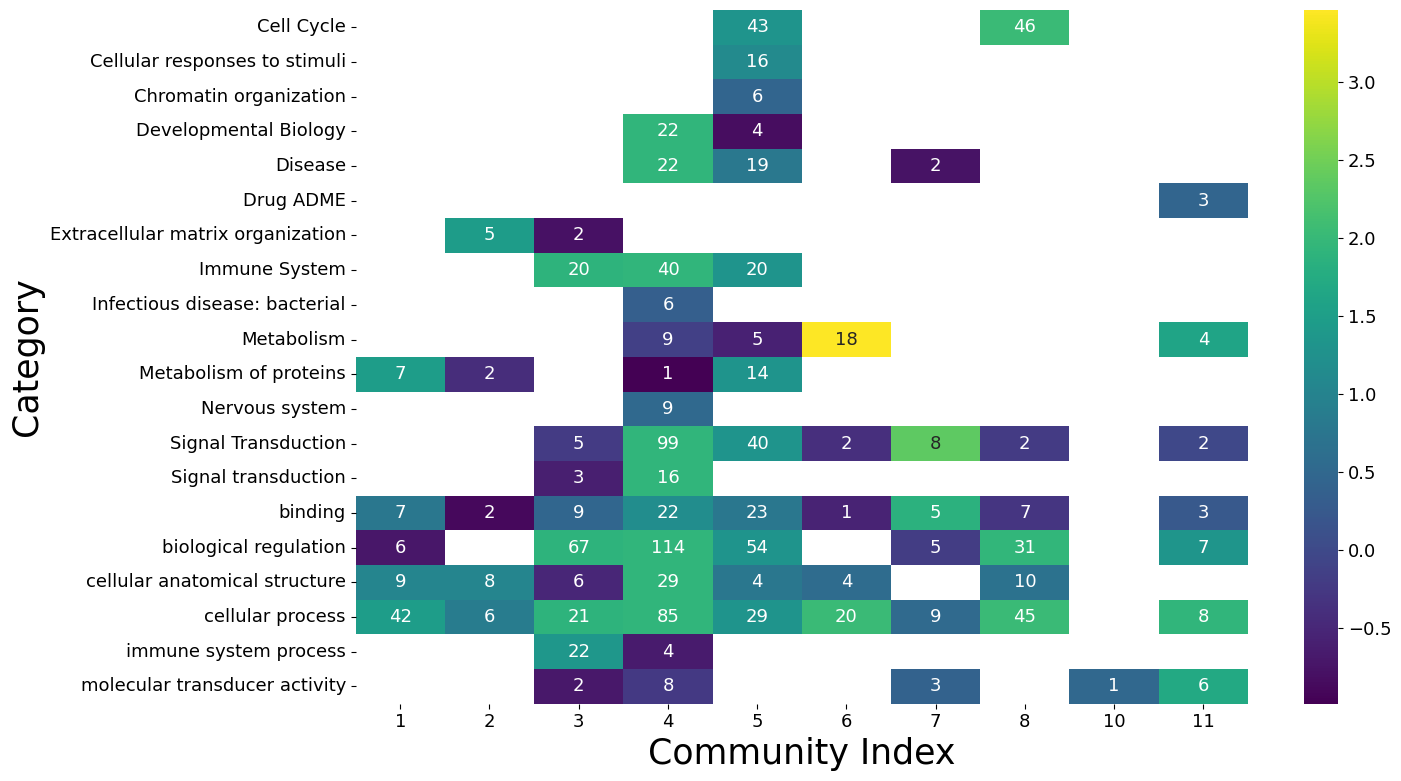

In [ ]:
heat_df = community_categories_filtered.pivot(
    index="Category",
    columns="Community Index",
    values="fisher_z"
)

label_df = community_categories_filtered.pivot(
    index="Category",
    columns="Community Index",
    values="count"
)
plt.figure(figsize=(15, 8))
ax = sns.heatmap(
    heat_df,
    cmap="viridis",
    annot=label_df,   # <-- use count for labels
    fmt=".0f",        # integer labels
    cbar=True
)

# ---- WRAP Y-AXIS LABELS ----
MAX_CHARS = 50  # tweak this
wrapped = ["\n".join(textwrap.wrap(str(s), width=MAX_CHARS)) for s in heat_df.index]
ax.set_yticklabels(wrapped, rotation=0)  # keep horizontal

plt.tight_layout()
plt.savefig(f"../../Graphs/{DISEASE}/category_gross_overlap_heatmap.pdf", bbox_inches="tight", dpi = 300)
plt.show()


# Dominant categories and terms analysis

In [ ]:
top_categories = (
    community_categories.groupby("Category")["fisher_z"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

In [ ]:
top_categories

Category
Immune System                    1.712883
Cell Cycle                       1.670529
cellular process                 1.553749
Cellular responses to stimuli    1.131586
Metabolism                       1.087109
biological regulation            1.073985
cellular anatomical structure    0.791321
Signal Transduction              0.679585
Signal transduction              0.657834
Disease                          0.647453
Name: fisher_z, dtype: float64